In [1]:
# importing needed packages
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy import stats
# import cartopy.crs as ccrs
# import cartopy.feature as cfeature
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [2]:
# read in the cleaned CSV with data from central valley stations
path = 'E:/Central Valley Fog/CV_station_rows_nonna.csv'
if os.path.exists(path):
    CV_rows = pd.read_csv(path, low_memory = False)
else:
    path = '/Volumes/disk1/Central Valley Fog/CV_station_rows_nonna.csv'
    CV_rows = pd.read_csv(path, low_memory = False)

print(CV_rows)

          STATION_ID  LATITUDE  LONGITUDE                 DATE REPORT_TYPE  \
0        USW00093193   36.7800  -119.7194  1941-12-04 00:00:00         SAO   
1        USW00093193   36.7800  -119.7194  1941-12-04 01:00:00         SAO   
2        USW00093193   36.7800  -119.7194  1941-12-04 02:00:00         SAO   
3        USW00093193   36.7800  -119.7194  1941-12-04 03:00:00         SAO   
4        USW00093193   36.7800  -119.7194  1941-12-04 04:00:00         SAO   
...              ...       ...        ...                  ...         ...   
8221089  USW00024257   40.5175  -122.2986  2026-06-20 04:53:00       FM-15   
8221090  USW00024257   40.5175  -122.2986  2026-06-20 05:53:00       FM-15   
8221091  USW00024257   40.5175  -122.2986  2026-06-20 06:53:00       FM-15   
8221092  USW00024257   40.5175  -122.2986  2026-06-20 07:53:00       FM-15   
8221093  USW00024257   40.5175  -122.2986  2026-06-20 08:53:00       FM-15   

         HourlyDewPointTemperature  HourlyDryBulbTemperature  \

In [3]:
# Exclude days from April through October (months 4-10) in CV_rows
CV_rows = CV_rows[~CV_rows['month'].isin([4, 5, 6, 7, 8, 9, 10])]

print("CV_rows after removing April-October:", CV_rows.shape)

CV_rows after removing April-October: (3634348, 18)


In [4]:
CV_rows = CV_rows[CV_rows["HourlyVisibility"] < 17]

print(CV_rows.shape)

(3634348, 18)


In [5]:
# Drop duplicate station-hours
CV_rows = CV_rows.drop_duplicates(subset=['STATION', 'year', 'month', 'day', 'hour'])

print("CV_rows after dropping duplicate station-hours:", CV_rows.shape)

CV_rows after dropping duplicate station-hours: (3035802, 18)


In [6]:
CV_rows['HourlyDewpointDepression'] = (
    CV_rows['HourlyDryBulbTemperature'] - CV_rows['HourlyDewPointTemperature']
)

CV_rows[['HourlyDryBulbTemperature', 'HourlyDewPointTemperature', 'HourlyDewpointDepression']].head()

,HourlyDryBulbTemperature,HourlyDewPointTemperature,HourlyDewpointDepression
0,5.2,4.1,1.1
1,4.6,3.5,1.1
2,4.1,3.0,1.1
3,3.0,1.9,1.1
4,2.4,1.3,1.1


In [7]:
# Determine rows with fog (visibility < 1 and precipitation < 0.03)
CV_fog_rows = CV_rows[(CV_rows['HourlyVisibility'] < 1) & (CV_rows['HourlyPrecipitation'] < 0.03)]
print("CV_fog_rows after filtering for fog conditions:", CV_fog_rows.shape)

CV_fog_rows after filtering for fog conditions: (137399, 19)


In [8]:
# Determine rows with heavy fog (visibility < 0.403 and precipitation < 0.03)
CV_heavy_fog_rows = CV_rows[(CV_rows['HourlyVisibility'] < 0.403) & (CV_rows['HourlyPrecipitation'] < 0.03)]
print("CV_heavy_fog_rows after filtering for heavy fog conditions:", CV_heavy_fog_rows.shape)

CV_heavy_fog_rows after filtering for heavy fog conditions: (106538, 19)


In [9]:
#Display column names 
CV_rows.columns

Index(['STATION_ID', 'LATITUDE', 'LONGITUDE', 'DATE', 'REPORT_TYPE',
       'HourlyDewPointTemperature', 'HourlyDryBulbTemperature',
       'HourlyPrecipitation', 'HourlyVisibility', 'HourlyWindDirection',
       'HourlyWindSpeed', 'MonthlyNumberDaysWithHeavyFog', 'year', 'month',
       'day', 'hour', 'minute', 'STATION', 'HourlyDewpointDepression'],
      dtype='str')

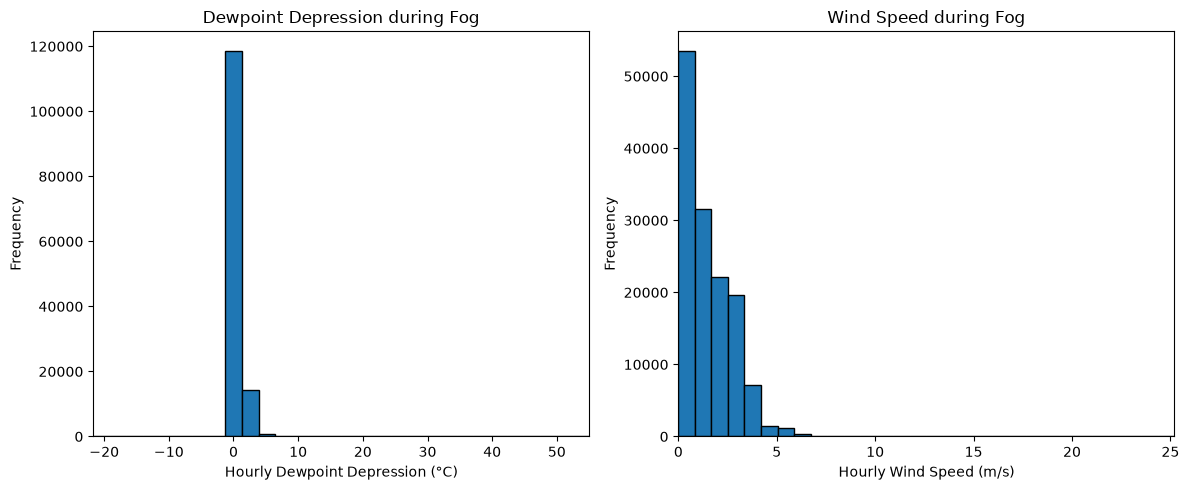

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Histogram for Hourly Dewpoint Depression
axes[0].hist(CV_fog_rows['HourlyDewpointDepression'].dropna(), bins=30, edgecolor='black')
axes[0].set_title('Dewpoint Depression during Fog')
axes[0].set_xlabel('Hourly Dewpoint Depression (°C)')
axes[0].set_ylabel('Frequency')
# set axes to be from the minimum to the maximum value of the data
axes[0].set_xlim(CV_fog_rows['HourlyDewpointDepression'].min(), CV_fog_rows['HourlyDewpointDepression'].max())

# Histogram for Hourly Wind Speed
axes[1].hist(CV_fog_rows['HourlyWindSpeed'].dropna(), bins=30, edgecolor='black')
axes[1].set_title('Wind Speed during Fog')
axes[1].set_xlabel('Hourly Wind Speed (m/s)')
axes[1].set_ylabel('Frequency')
# set axes to be from the minimum to the maximum value of the data
axes[1].set_xlim(CV_fog_rows['HourlyWindSpeed'].min(), CV_fog_rows['HourlyWindSpeed'].max())

plt.tight_layout()
plt.show()

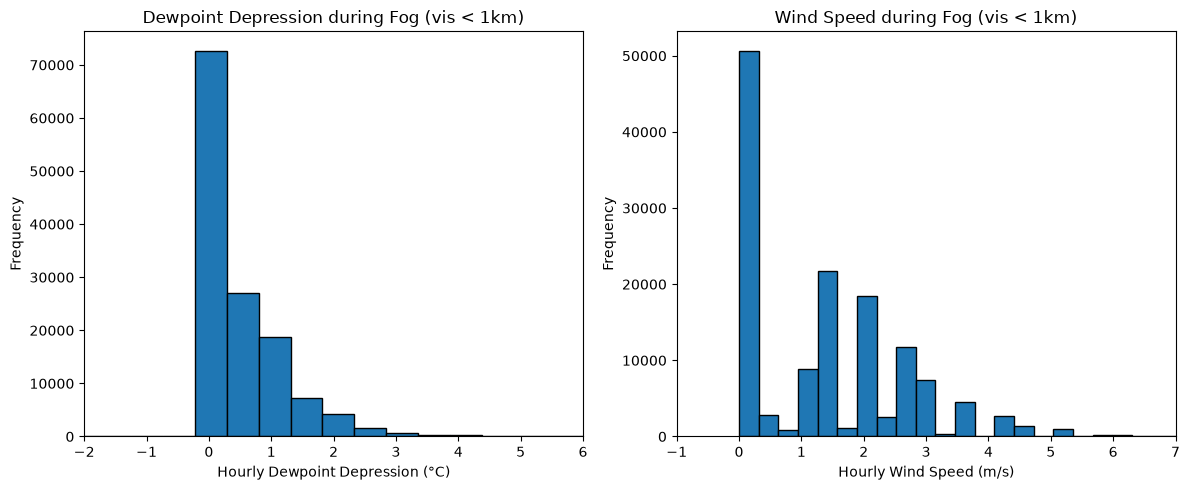

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(
    CV_fog_rows['HourlyDewpointDepression'].dropna(),
    bins=150,
    edgecolor='black'
)
axes[0].set_title('Dewpoint Depression during Fog (vis < 1km)')
axes[0].set_xlabel('Hourly Dewpoint Depression (°C)')
axes[0].set_ylabel('Frequency')
axes[0].set_xlim(-2, 6)

axes[1].hist(
    CV_fog_rows['HourlyWindSpeed'].dropna(),
    bins=80,
    edgecolor='black'
)
axes[1].set_title('Wind Speed during Fog (vis < 1km)')
axes[1].set_xlabel('Hourly Wind Speed (m/s)')
axes[1].set_ylabel('Frequency')
axes[1].set_xlim(-1, 7)

plt.tight_layout()
plt.show()

In [12]:
# Percentage of fog rows with dewpoint depression between -1 and 4 °C
# and wind speed below 5 m/s
matching_rows = CV_fog_rows[
    CV_fog_rows['HourlyDewpointDepression'].between(-1, 3.5, inclusive='both')
    & (CV_fog_rows['HourlyWindSpeed'] < 5)
]

percentage = 100 * len(matching_rows) / len(CV_fog_rows)

print(f"Matching fog rows: {len(matching_rows):,}")
print(f"Percentage of fog rows: {percentage:.2f}%")

Matching fog rows: 130,893
Percentage of fog rows: 95.26%


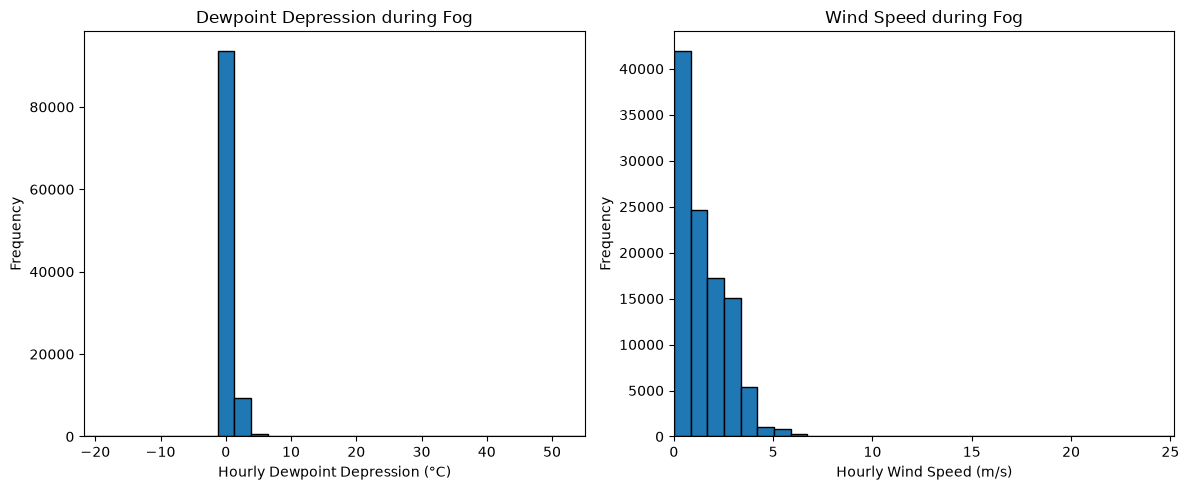

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Histogram for Hourly Dewpoint Depression
axes[0].hist(CV_heavy_fog_rows['HourlyDewpointDepression'].dropna(), bins=30, edgecolor='black')
axes[0].set_title('Dewpoint Depression during Fog')
axes[0].set_xlabel('Hourly Dewpoint Depression (°C)')
axes[0].set_ylabel('Frequency')
# set axes to be from the minimum to the maximum value of the data
axes[0].set_xlim(CV_heavy_fog_rows['HourlyDewpointDepression'].min(), CV_heavy_fog_rows['HourlyDewpointDepression'].max())

# Histogram for Hourly Wind Speed
axes[1].hist(CV_heavy_fog_rows['HourlyWindSpeed'].dropna(), bins=30, edgecolor='black')
axes[1].set_title('Wind Speed during Fog')
axes[1].set_xlabel('Hourly Wind Speed (m/s)')
axes[1].set_ylabel('Frequency')
# set axes to be from the minimum to the maximum value of the data
axes[1].set_xlim(CV_heavy_fog_rows['HourlyWindSpeed'].min(), CV_heavy_fog_rows['HourlyWindSpeed'].max())

plt.tight_layout()
plt.show()

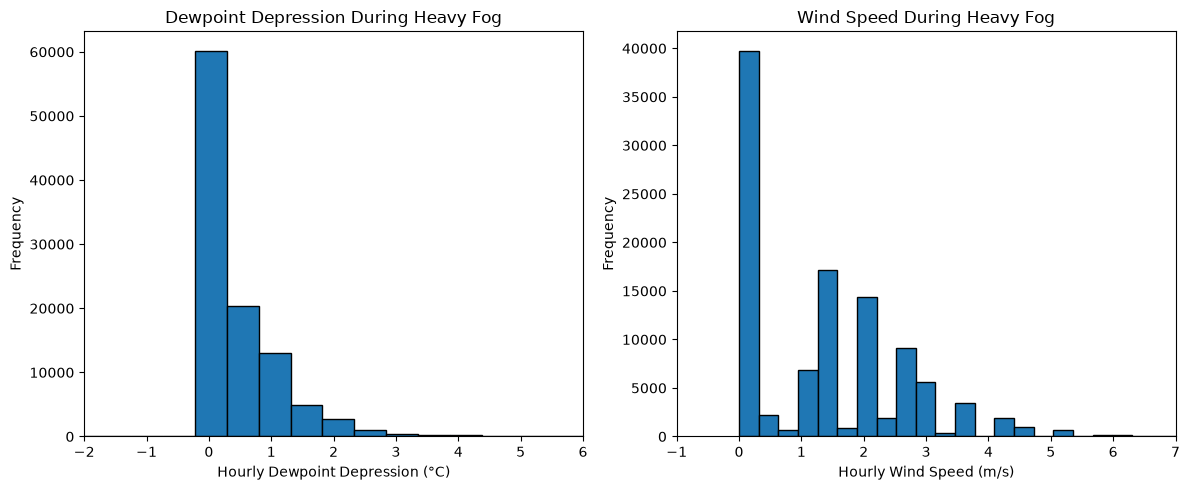

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(
    CV_heavy_fog_rows['HourlyDewpointDepression'].dropna(),
    bins=150,
    edgecolor='black'
)
axes[0].set_title('Dewpoint Depression During Heavy Fog')
axes[0].set_xlabel('Hourly Dewpoint Depression (°C)')
axes[0].set_ylabel('Frequency')
axes[0].set_xlim(-2, 6)

axes[1].hist(
    CV_heavy_fog_rows['HourlyWindSpeed'].dropna(),
    bins=80,
    edgecolor='black'
)
axes[1].set_title('Wind Speed During Heavy Fog')
axes[1].set_xlabel('Hourly Wind Speed (m/s)')
axes[1].set_ylabel('Frequency')
axes[1].set_xlim(-1, 7)

plt.tight_layout()
plt.show()

In [15]:
# Percentage of fog rows with dewpoint depression between -1 and 4 °C
# and wind speed below 5 m/s
matching_rows_h = CV_heavy_fog_rows[
    CV_heavy_fog_rows['HourlyDewpointDepression'].between(-1, 3.5, inclusive='both')
    & (CV_heavy_fog_rows['HourlyWindSpeed'] < 5)
]

percentage = 100 * len(matching_rows_h) / len(CV_heavy_fog_rows)

print(f"Matching fog rows: {len(matching_rows_h):,}")
print(f"Percentage of fog rows: {percentage:.2f}%")

Matching fog rows: 101,718
Percentage of fog rows: 95.48%


In [16]:
matching_rows_cv = CV_rows[
    (CV_rows['HourlyDewpointDepression'] < 3.5)
    & (CV_rows['HourlyWindSpeed'] < 5)
]

lowvis_rows_cv = CV_rows[
    (CV_rows['HourlyDewpointDepression'] < 3.5)
    & (CV_rows['HourlyWindSpeed'] < 5)
    & (CV_rows['HourlyVisibility'] < 1)
]

percentage_fg = 100 * len(lowvis_rows_cv) / len(matching_rows_cv)

print(f"Matching rows: {len(matching_rows_cv):,}")
print(f"Low visibility rows: {len(lowvis_rows_cv):,}")
print(f"Percentage of rows with ideal fog conditions that have fog: {percentage_fg:.2f}%")

Matching rows: 1,358,343
Low visibility rows: 131,535
Percentage of rows with ideal fog conditions that have fog: 9.68%


In [17]:
matching_rows_cv2 = CV_rows[
    (CV_rows['HourlyDewpointDepression'] < 2)
    & (CV_rows['HourlyWindSpeed'] < 5)
]

lowvis_rows_cv2 = CV_rows[
    (CV_rows['HourlyDewpointDepression'] < 2)
    & (CV_rows['HourlyWindSpeed'] < 5)
    & (CV_rows['HourlyVisibility'] < 1)
]


percentage_fg2 = 100 * len(lowvis_rows_cv2) / len(matching_rows_cv2)

print(f"Matching rows: {len(matching_rows_cv2):,}")
print(f"Low visibility rows: {len(lowvis_rows_cv2):,}")
print(f"Percentage of rows with ideal fog conditions that have fog: {percentage_fg2:.2f}%")

Matching rows: 820,044
Low visibility rows: 124,864
Percentage of rows with ideal fog conditions that have fog: 15.23%


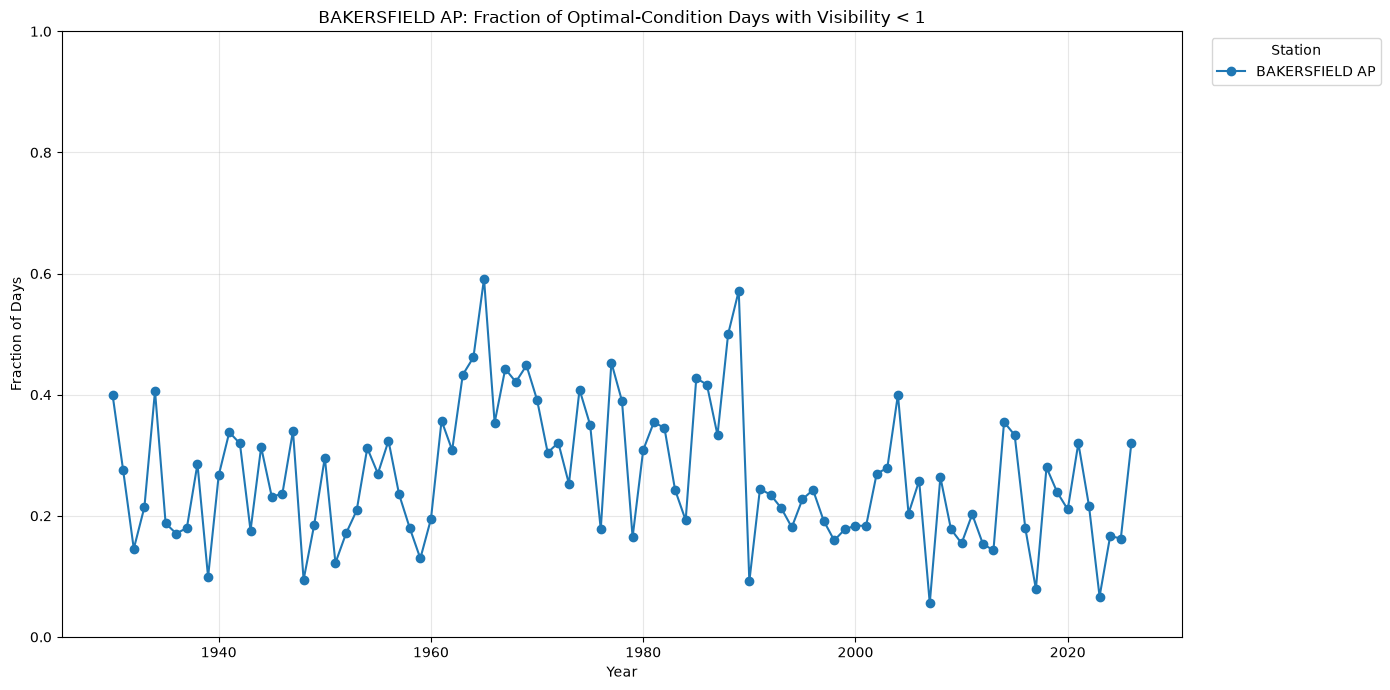

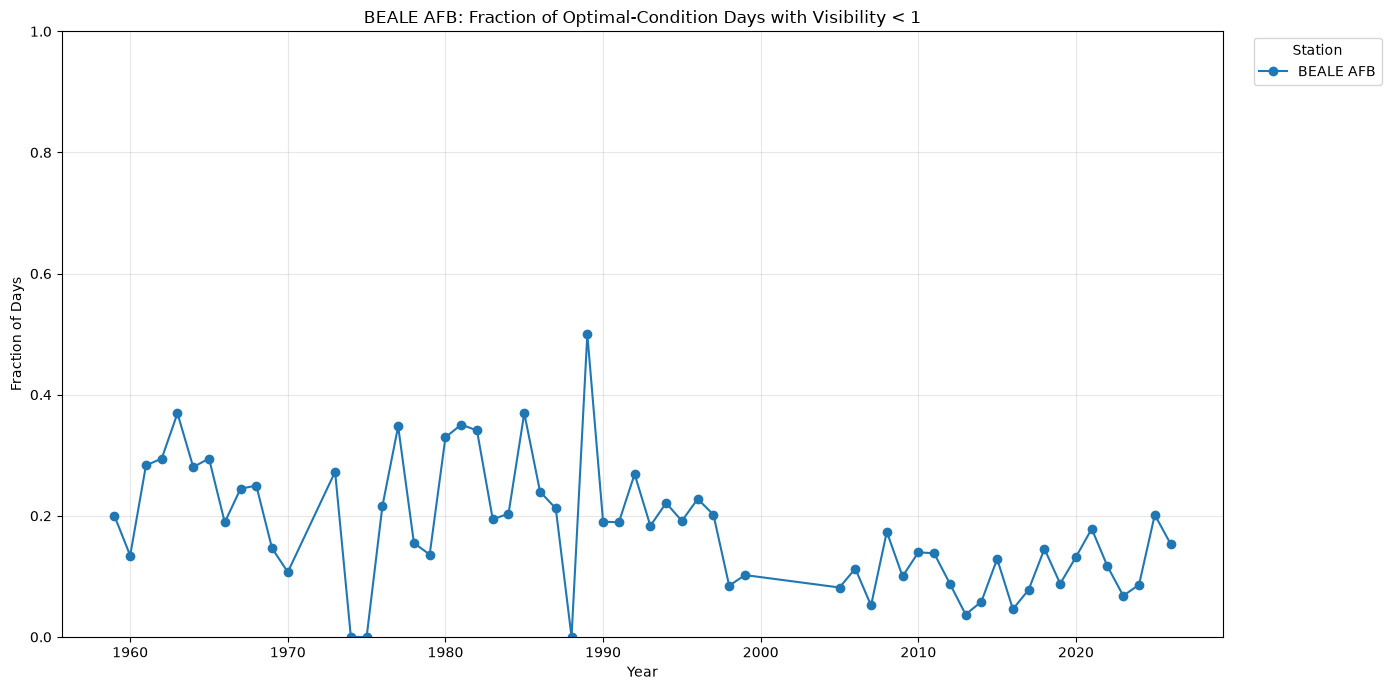

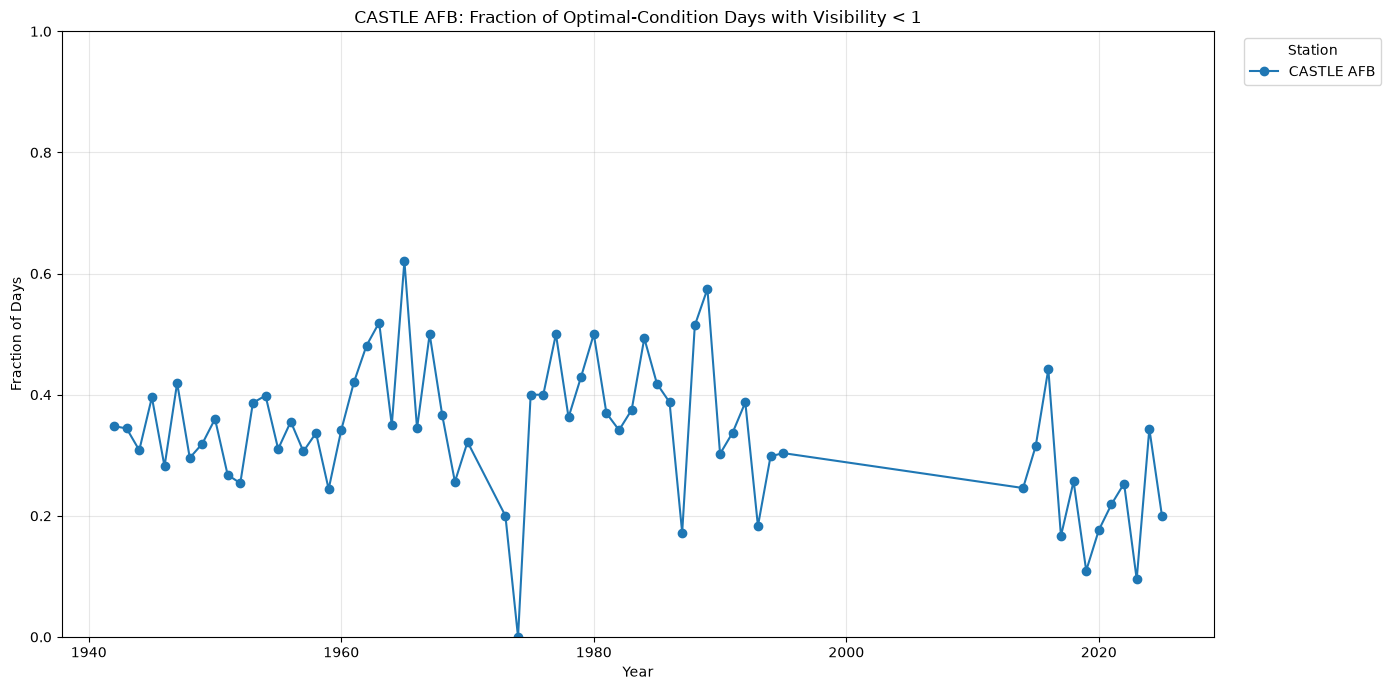

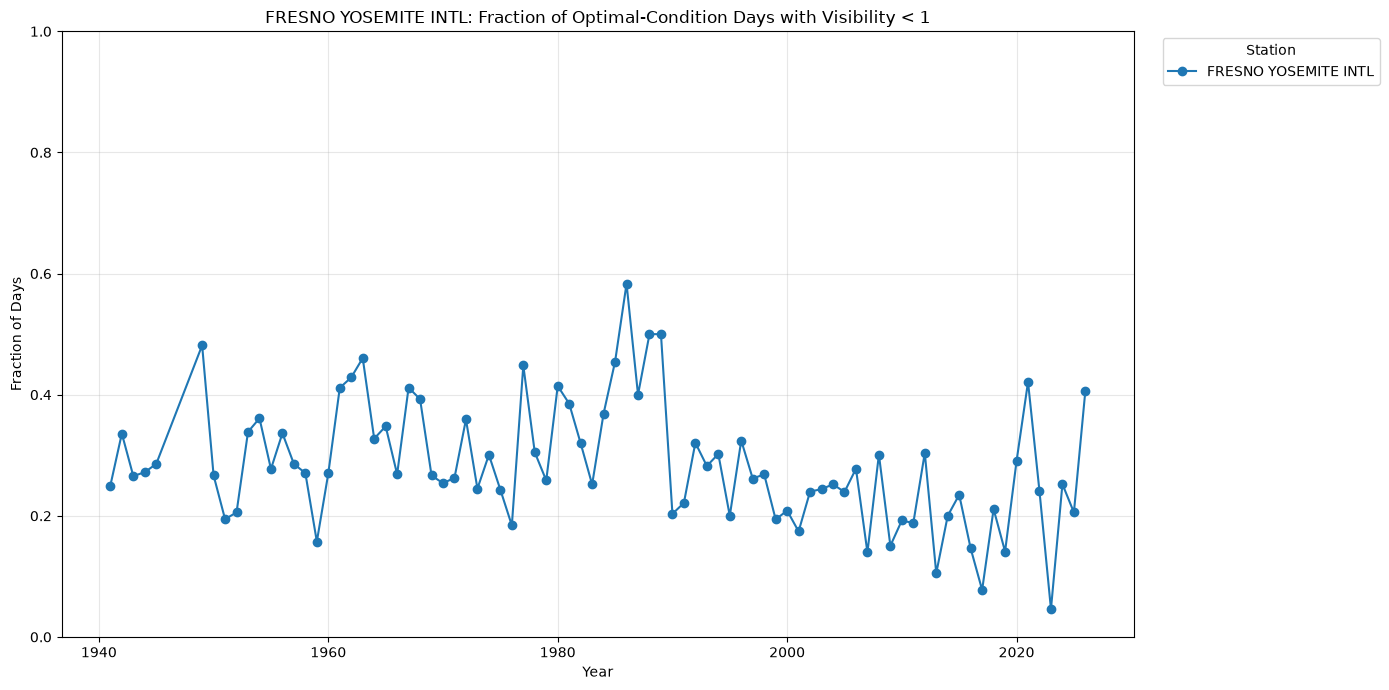

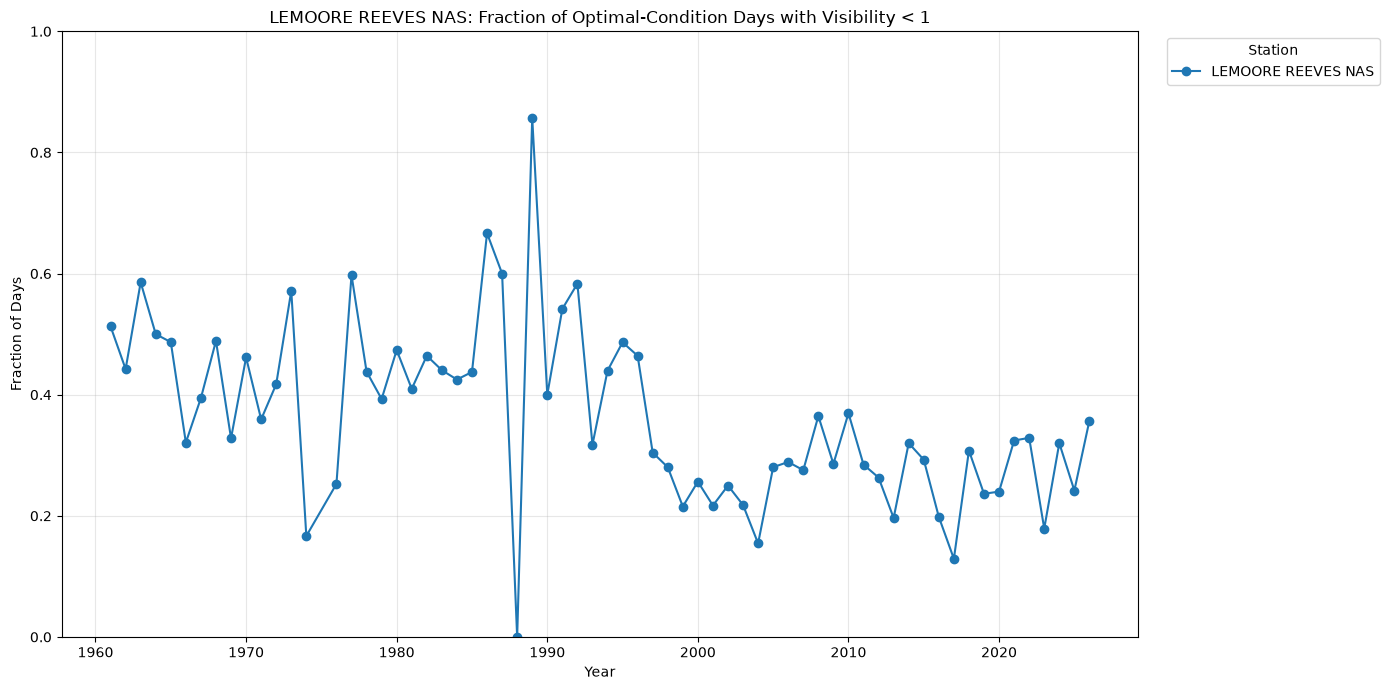

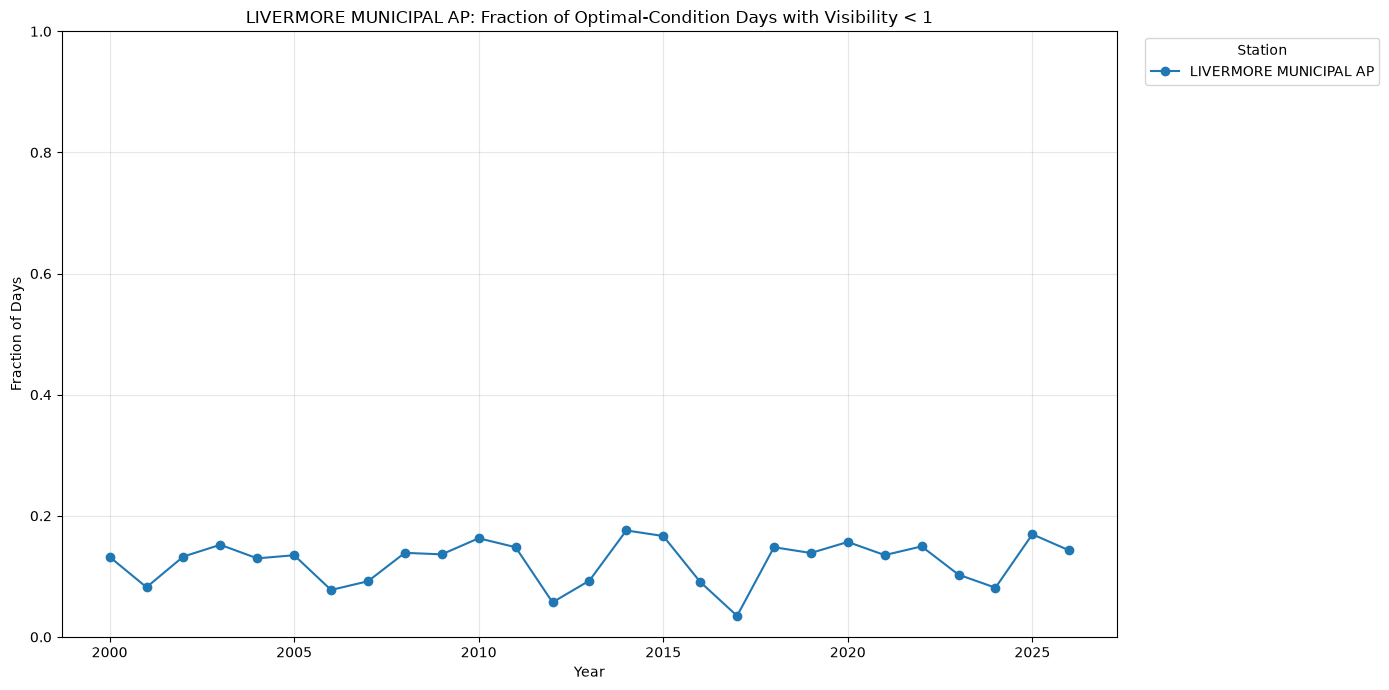

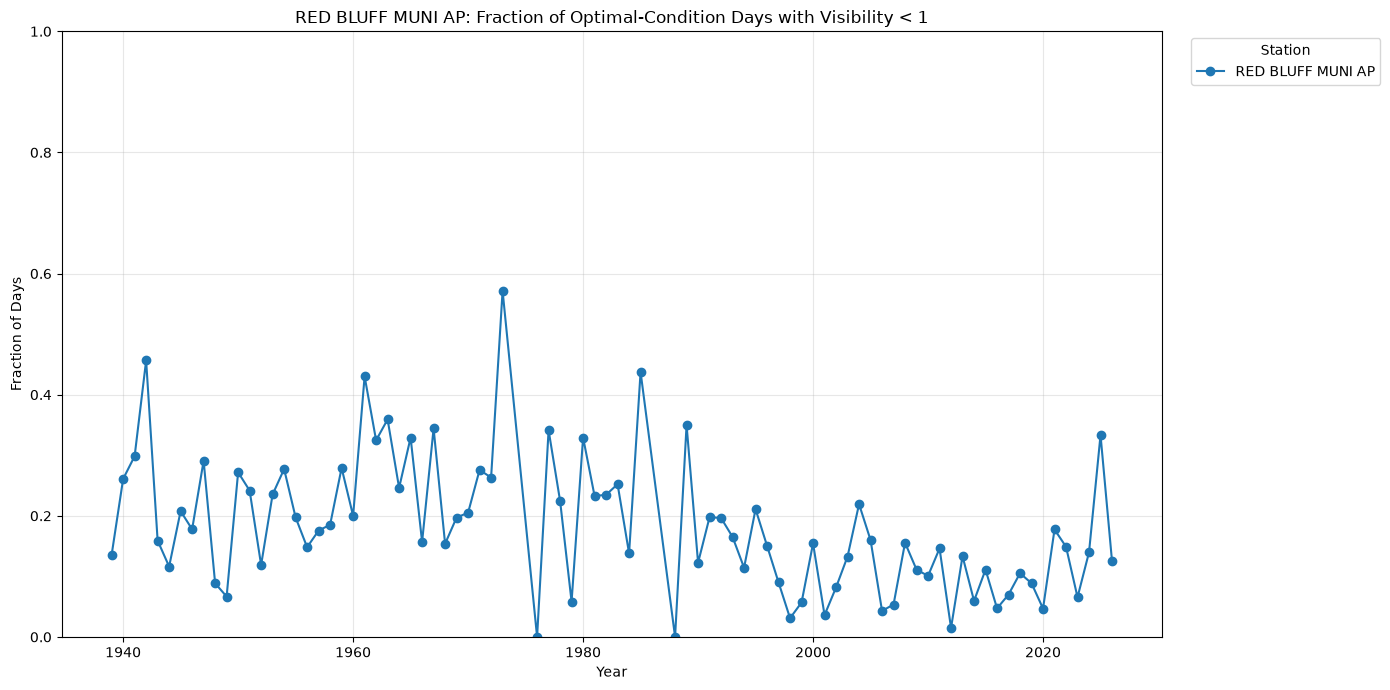

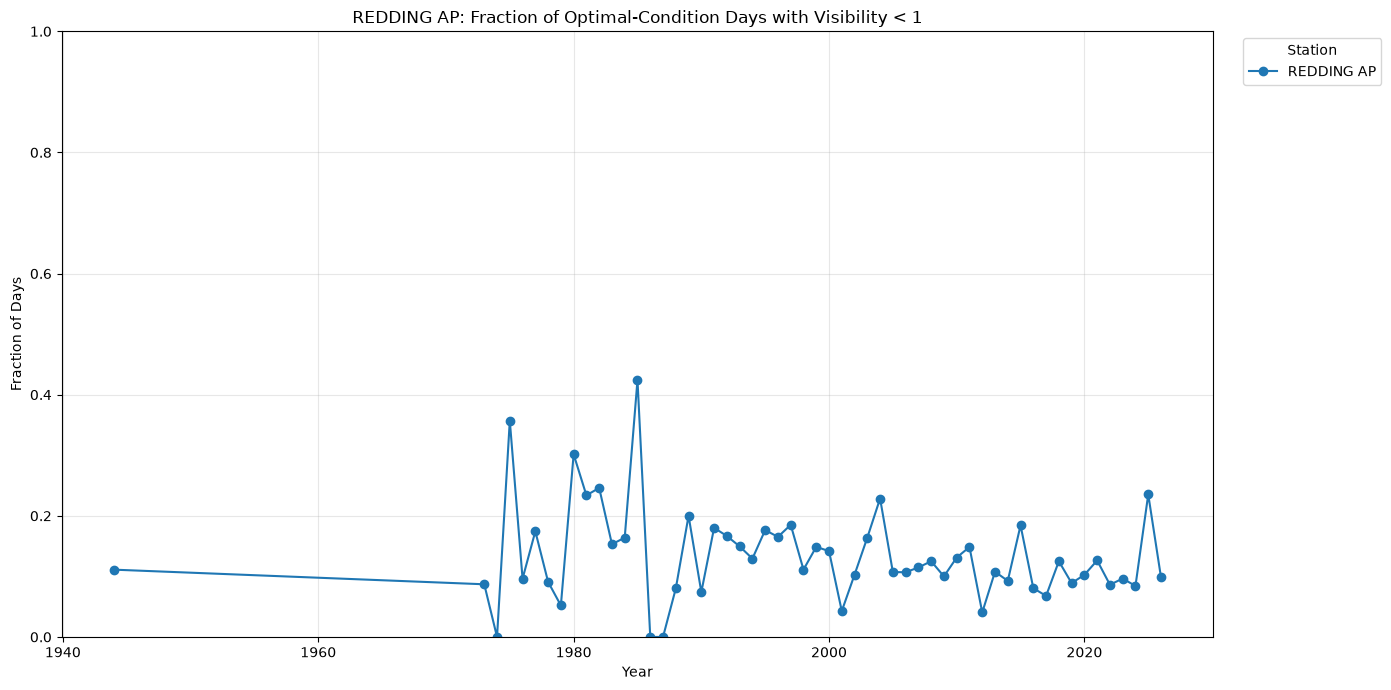

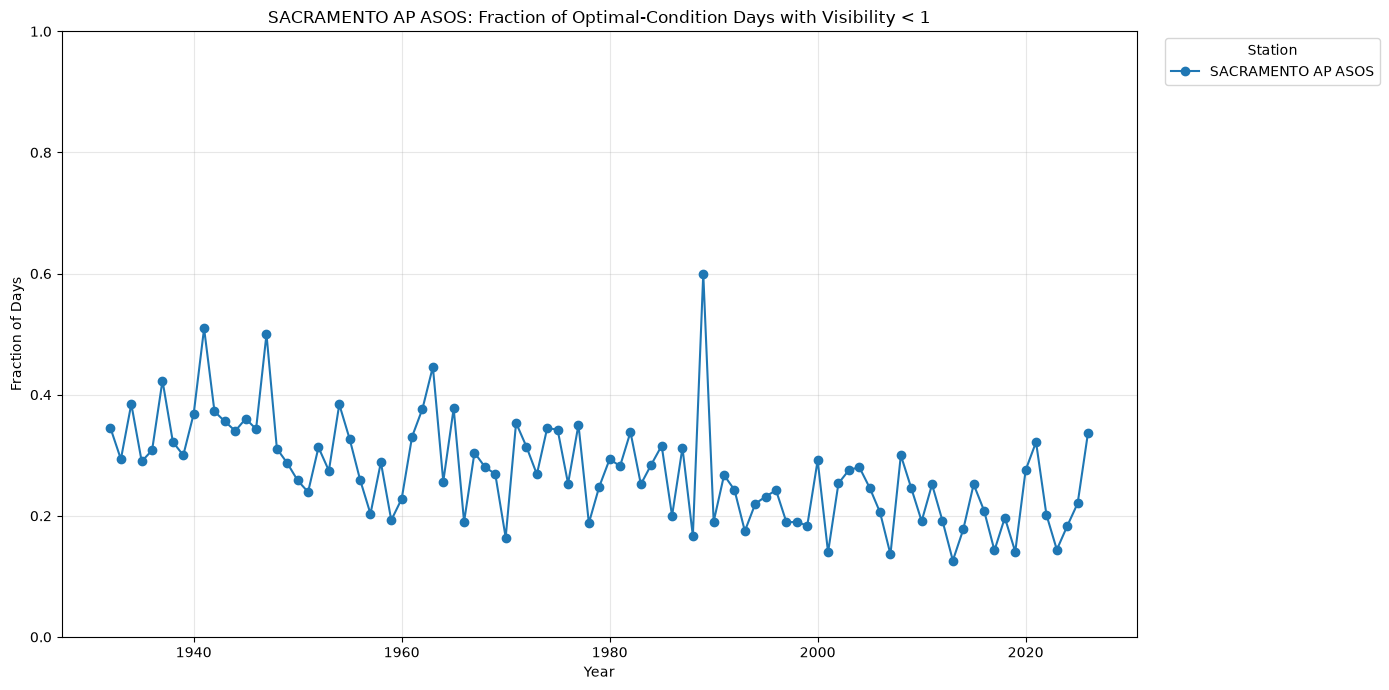

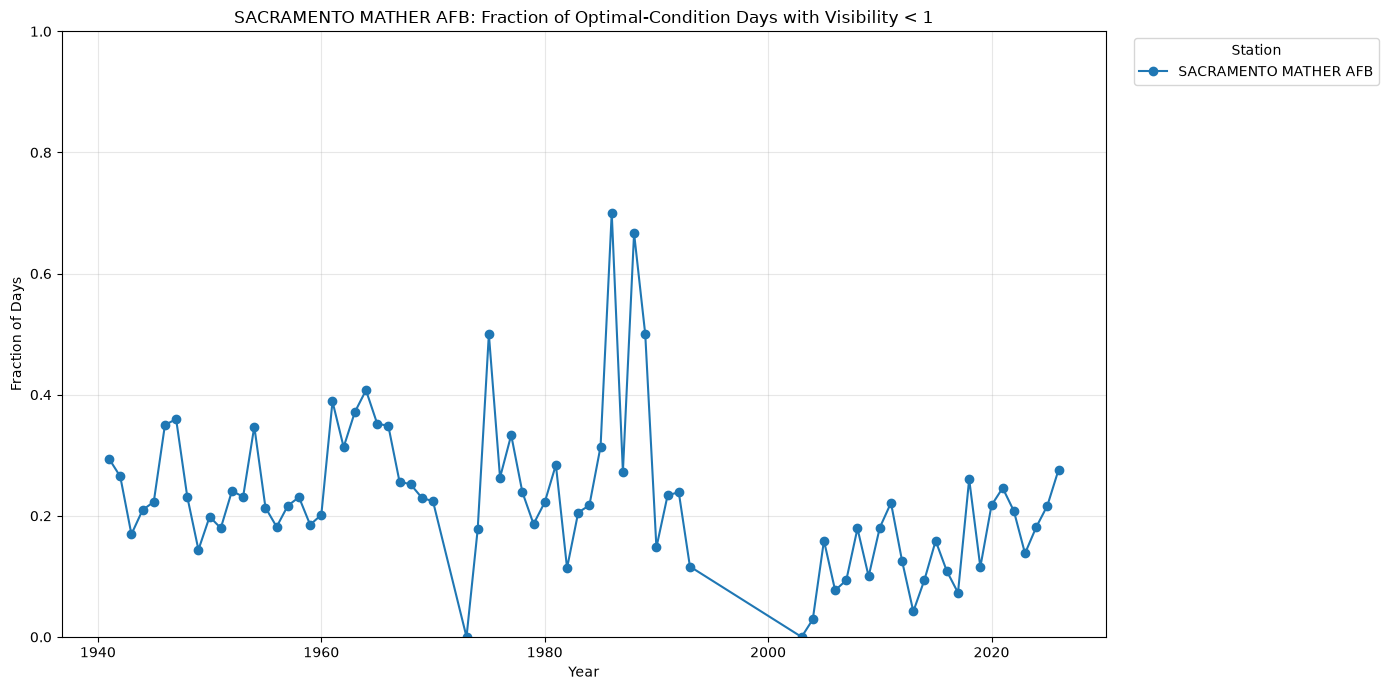

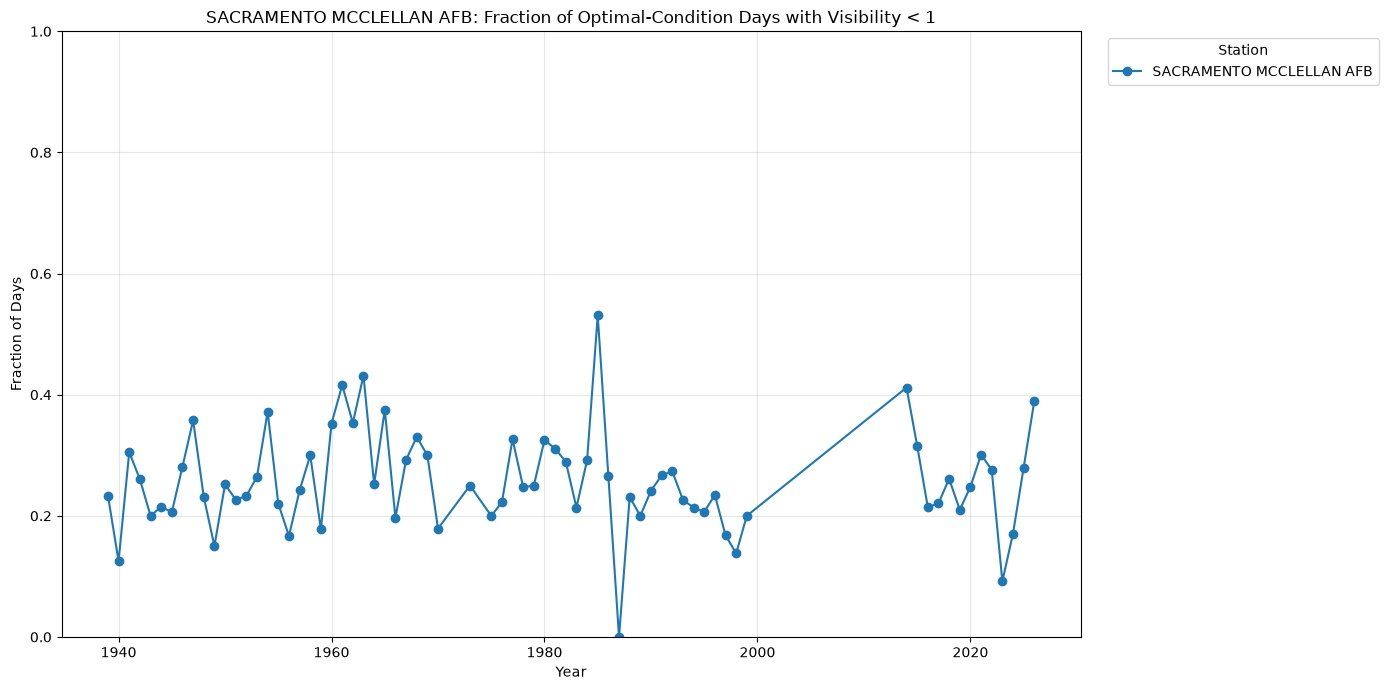

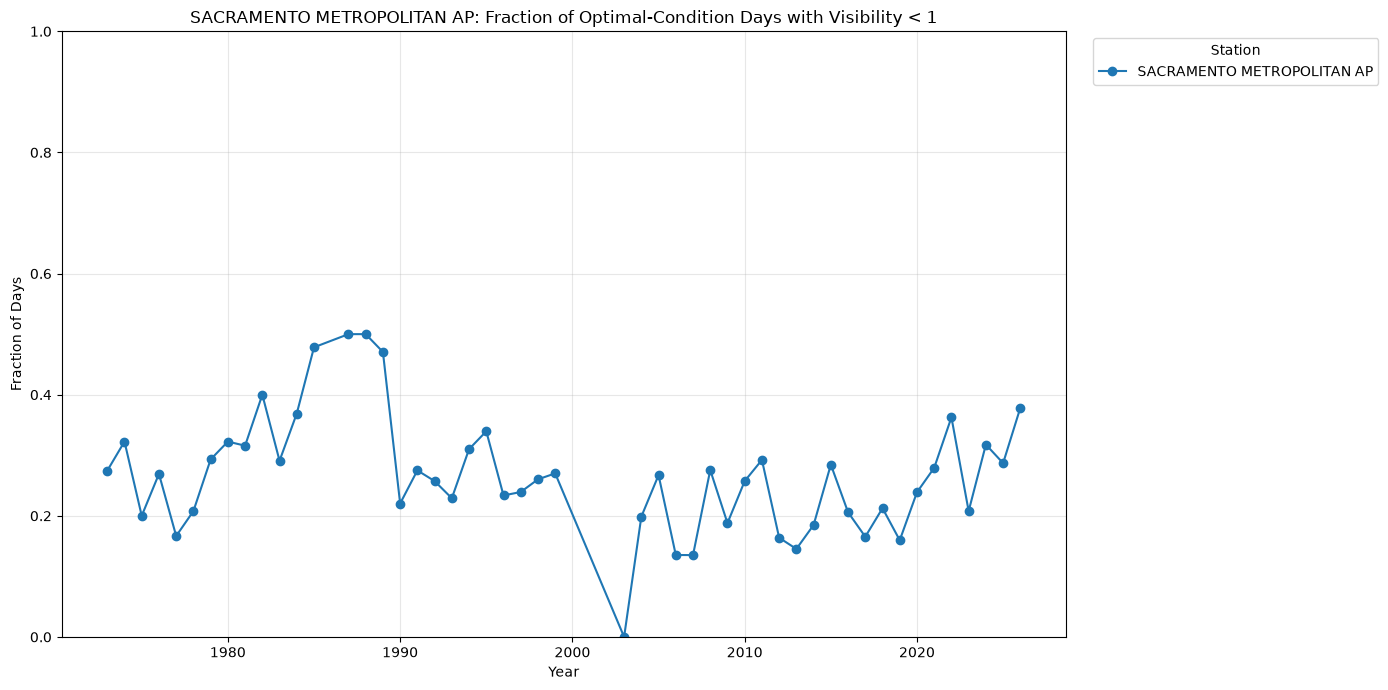

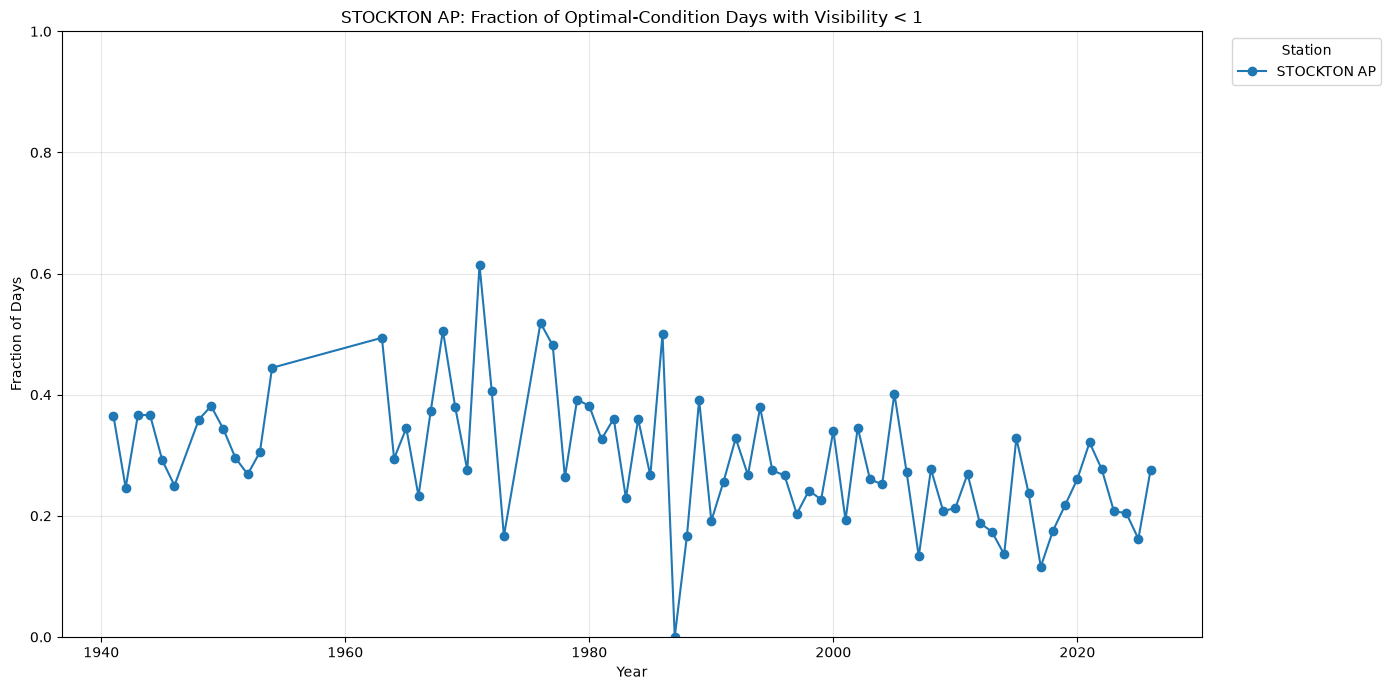

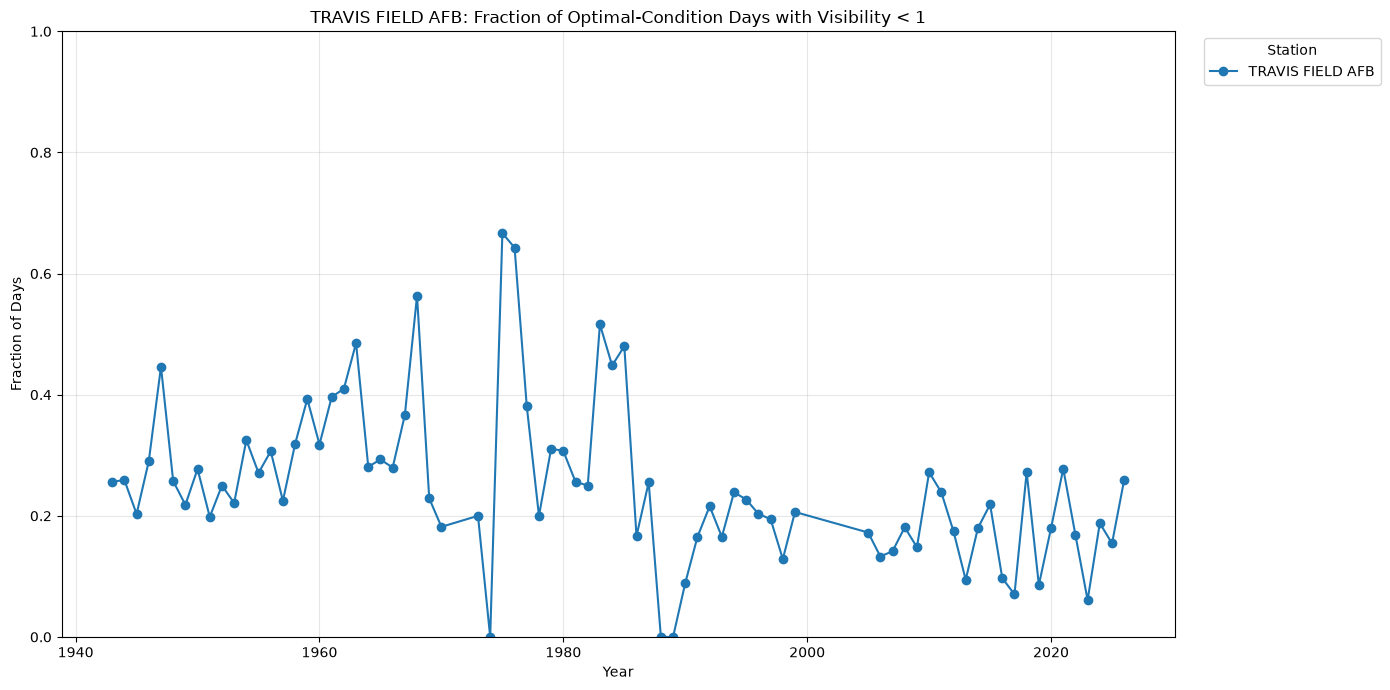

<Figure size 640x480 with 0 Axes>

,STATION,year,optimal_days,low_visibility_days,fog_fraction
0,BAKERSFIELD AP,1930,30,12,0.400000
1,BAKERSFIELD AP,1931,80,22,0.275000
2,BAKERSFIELD AP,1932,103,15,0.145631
3,BAKERSFIELD AP,1933,84,18,0.214286
4,BAKERSFIELD AP,1934,96,39,0.406250


In [18]:
# Identify days with optimal fog conditions and whether those days had visibility < 1
daily_conditions = CV_rows.copy()
daily_conditions["DATE"] = pd.to_datetime(daily_conditions["DATE"])
daily_conditions["date"] = daily_conditions["DATE"].dt.normalize()

daily_conditions["optimal_conditions"] = (
    (daily_conditions["HourlyDewpointDepression"] < 2)
    & (daily_conditions["HourlyWindSpeed"] < 5)
)

daily_conditions["low_visibility"] = (
    daily_conditions["optimal_conditions"]
    & (daily_conditions["HourlyVisibility"] < 1)
)

# Reduce multiple observations per day to one station-day record
station_days = (
    daily_conditions.groupby(["STATION", "year", "date"], as_index=False)
    .agg(
        optimal_conditions=("optimal_conditions", "any"),
        low_visibility=("low_visibility", "any")
    )
)

# Keep only days with optimal meteorological conditions
optimal_days_by_year = (
    station_days[station_days["optimal_conditions"]]
    .groupby(["STATION", "year"], as_index=False)
    .agg(
        optimal_days=("date", "nunique"),
        low_visibility_days=("low_visibility", "sum")
    )
)

optimal_days_by_year["fog_fraction"] = (
    optimal_days_by_year["low_visibility_days"]
    / optimal_days_by_year["optimal_days"]
)

# Plot the fraction for each station by year
# Make individual plots for each station
for station, station_data in optimal_days_by_year.groupby("STATION"):
    station_data = station_data.sort_values("year")

    fig, ax = plt.subplots(figsize=(14, 7))
    ax.plot(
        station_data["year"],
        station_data["fog_fraction"],
        marker="o",
        linewidth=1.5,
        label=station
    )

    ax.set_title(f"{station}: Fraction of Optimal-Condition Days with Visibility < 1")
    ax.set_xlabel("Year")
    ax.set_ylabel("Fraction of Days")
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)
    ax.legend(title="Station", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

ax.set_title("Fraction of Optimal-Condition Days with Visibility < 1")
ax.set_xlabel("Year")
ax.set_ylabel("Fraction of Days")
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)
ax.legend(title="Station", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

optimal_days_by_year.head()

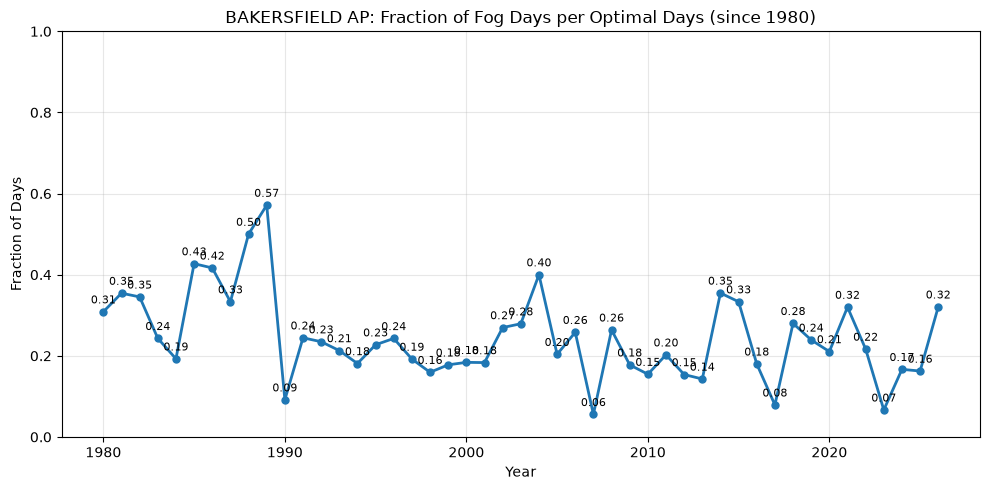

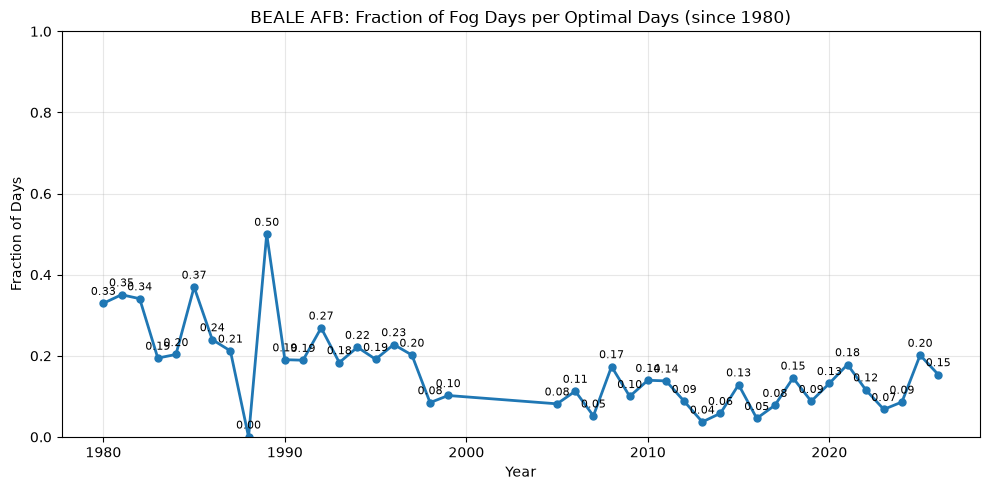

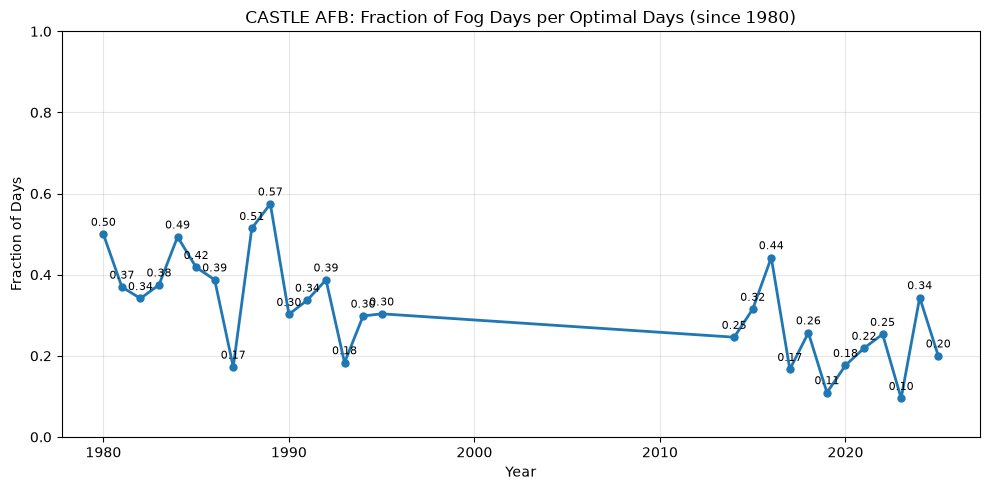

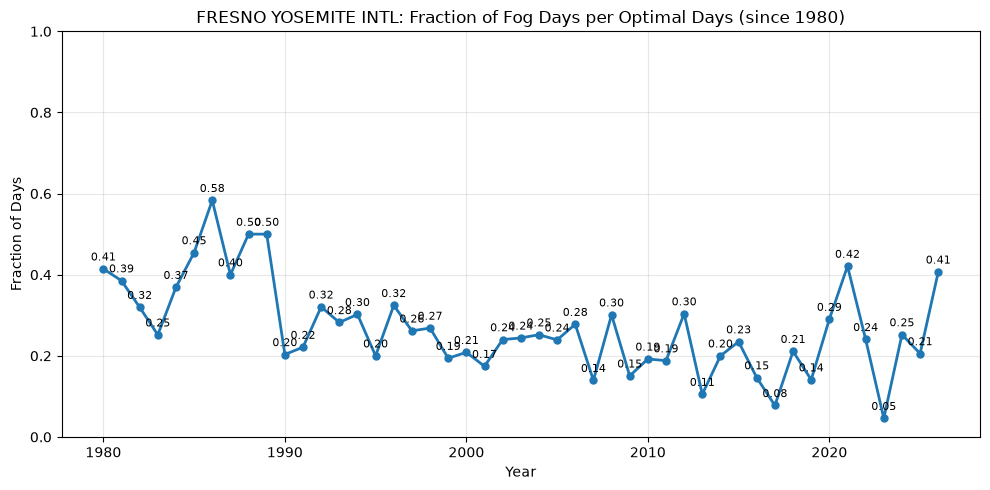

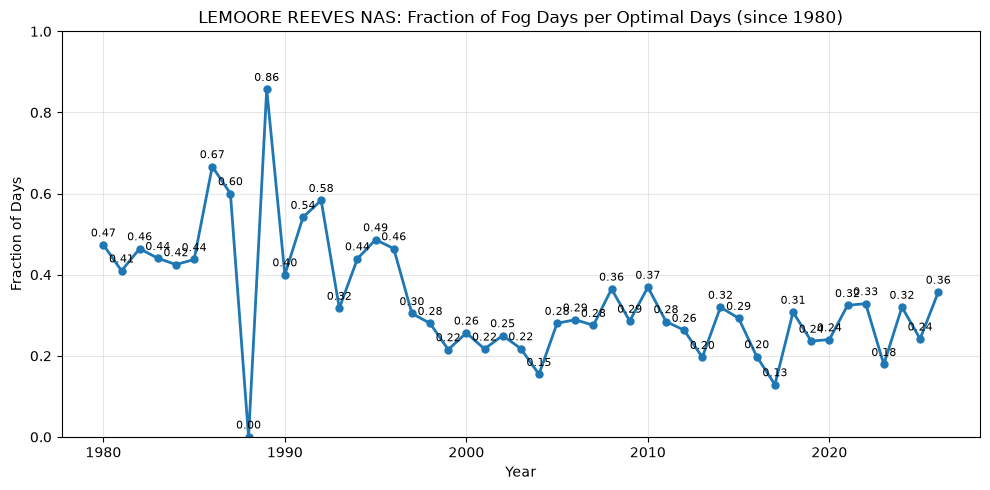

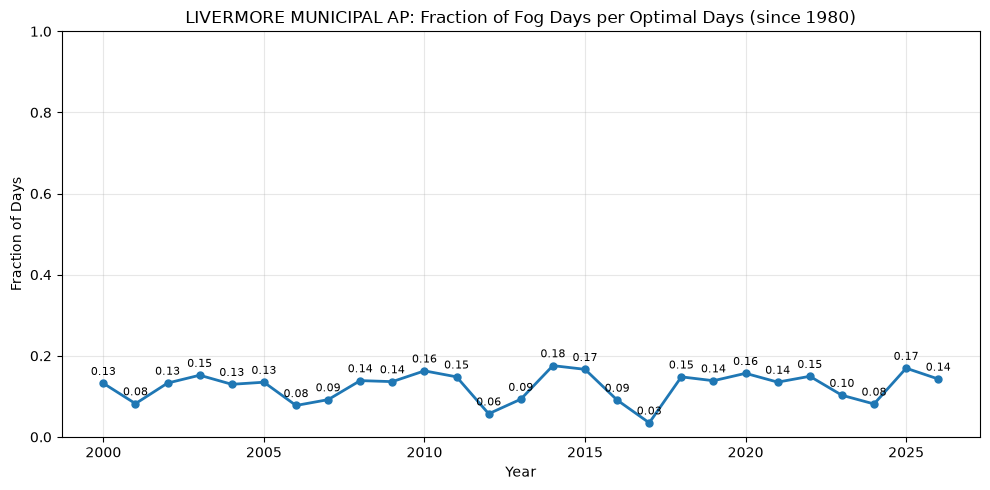

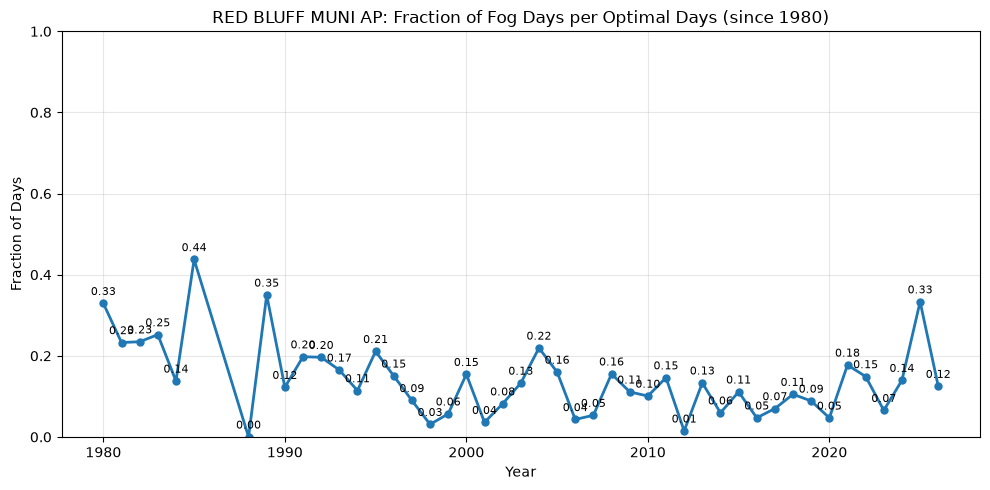

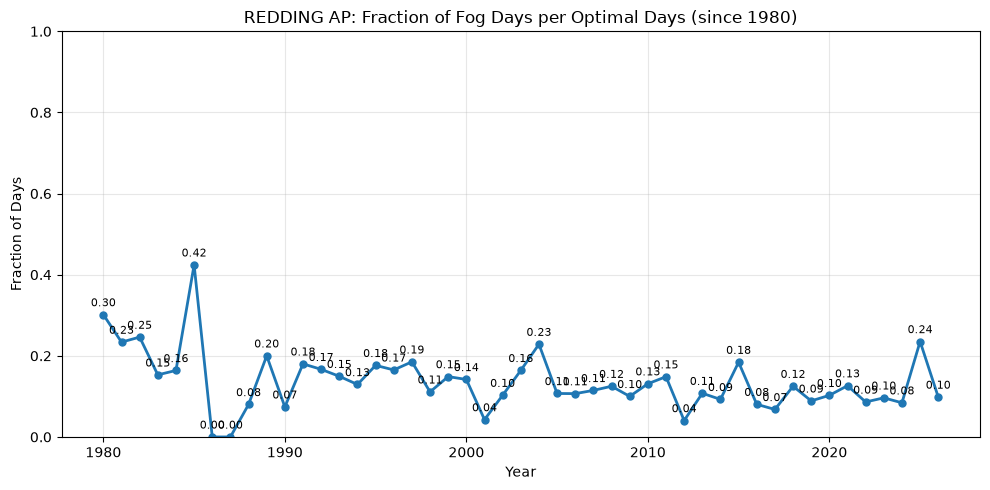

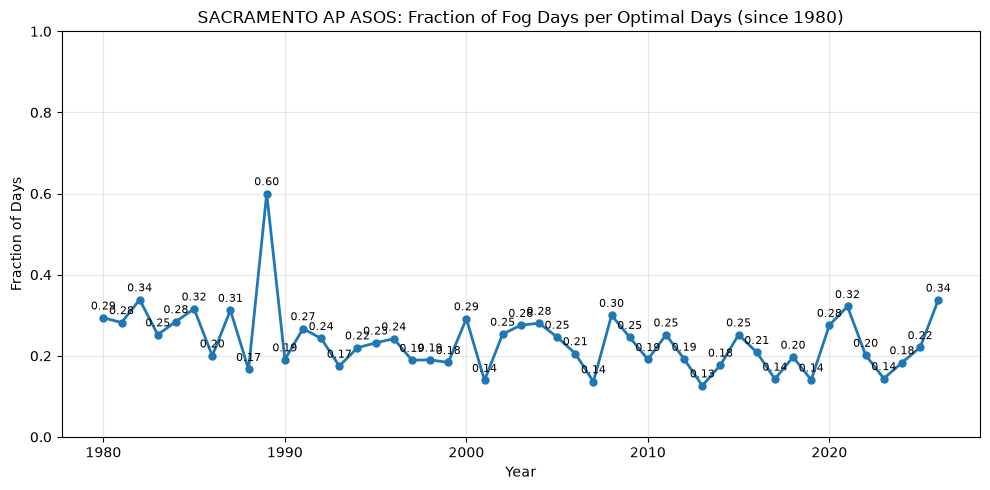

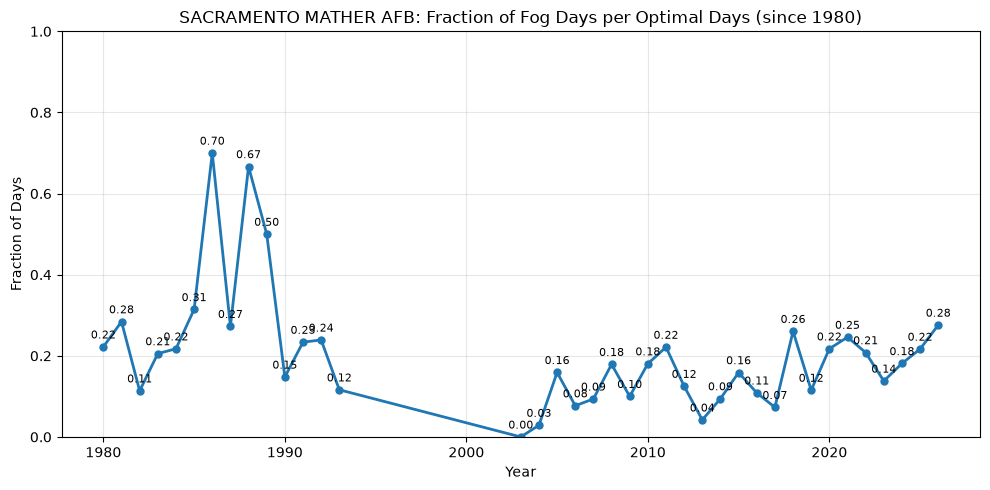

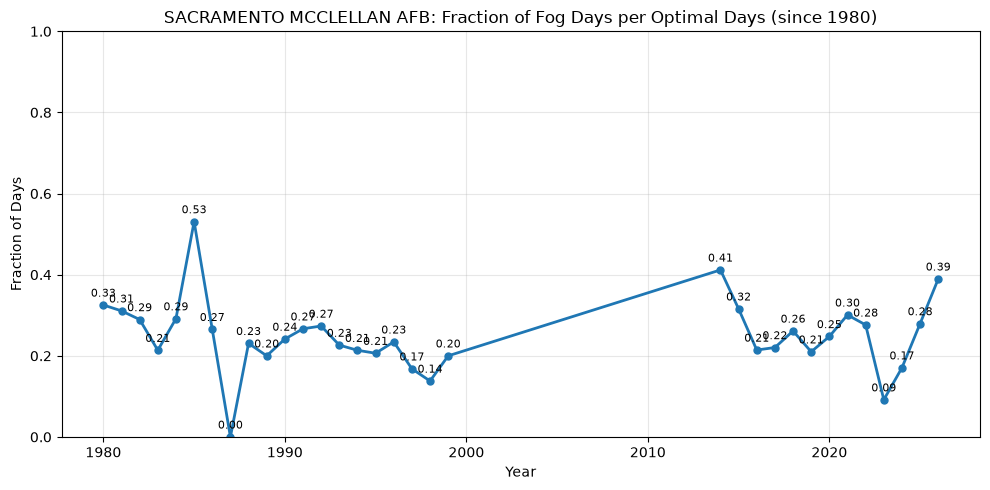

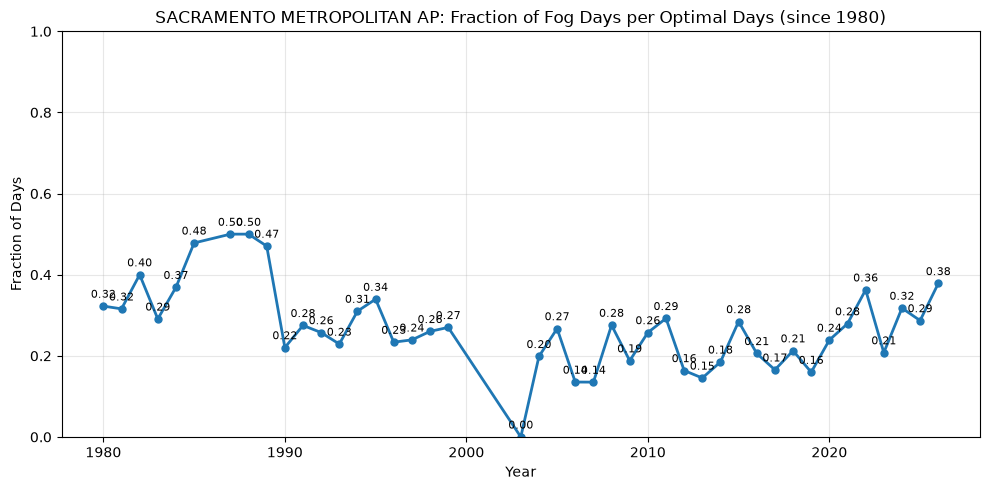

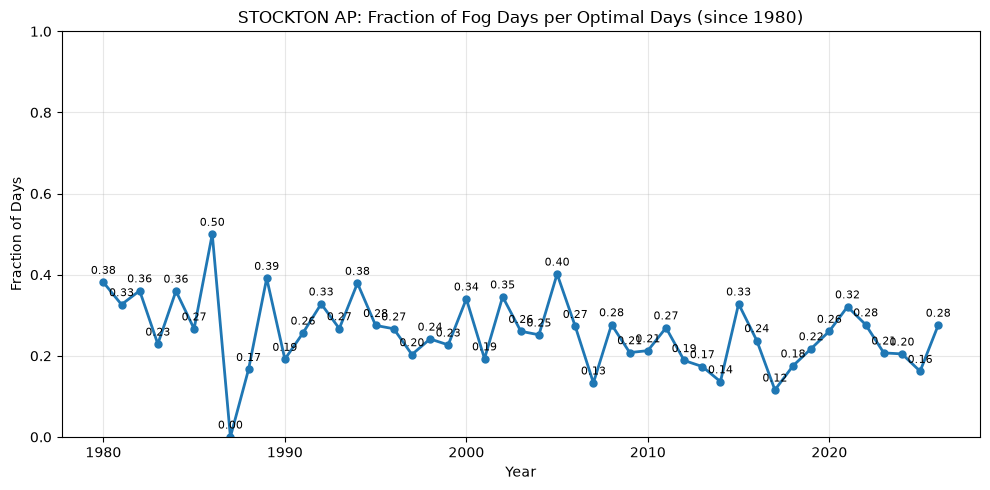

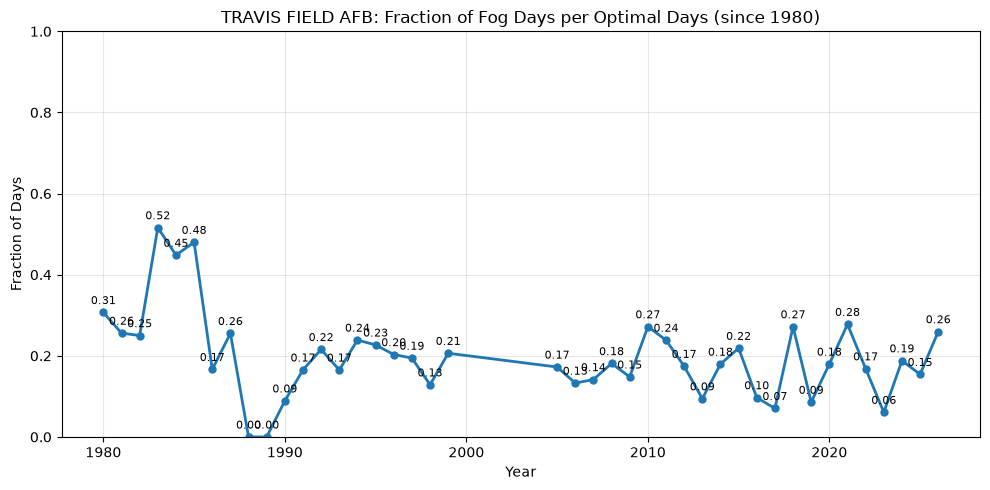

In [19]:
# Filter to years >= 1980 and create a separate plot for each station
plot_df = optimal_days_by_year[optimal_days_by_year["year"] >= 1980].copy()

# Ensure the fraction is defined for each station-year
plot_df = plot_df[plot_df["optimal_days"] > 0].copy()
plot_df["fog_fraction"] = plot_df["low_visibility_days"] / plot_df["optimal_days"]

for station, station_data in plot_df.groupby("STATION"):
    station_data = station_data.sort_values("year")

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(
        station_data["year"],
        station_data["fog_fraction"],
        marker="o",
        linewidth=2,
        markersize=5,
        color="tab:blue"
    )
    ax.set_title(f"{station}: Fraction of Fog Days per Optimal Days (since 1980)")
    ax.set_xlabel("Year")
    ax.set_ylabel("Fraction of Days")
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)

    # Optional: annotate points for readability
    for _, row in station_data.iterrows():
        ax.annotate(
            f"{row['fog_fraction']:.2f}",
            (row["year"], row["fog_fraction"]),
            textcoords="offset points",
            xytext=(0, 6),
            ha="center",
            fontsize=8,
            color="black"
        )

    plt.tight_layout()
    plt.show()